In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [47]:
""" 
Seviye 1 — Temel keşif

Bunlar veri setini tanıma aşaması.

Case 1
Dataset’in boyutunu bul: kaç satır, kaç sütun var?

Case 2
Kolon isimlerini ve veri tiplerini incele.

Case 3
Eksik değer var mı? Hangi kolonda kaç tane null değer var?

Case 4
Sayısal kolonlar için özet istatistik çıkar.
Özellikle satış kolonlarına bak: ortalama, min, max, yüzde 25-50-75.

"""

' \nSeviye 1 — Temel keşif\n\nBunlar veri setini tanıma aşaması.\n\nCase 1\nDataset’in boyutunu bul: kaç satır, kaç sütun var?\n\nCase 2\nKolon isimlerini ve veri tiplerini incele.\n\nCase 3\nEksik değer var mı? Hangi kolonda kaç tane null değer var?\n\nCase 4\nSayısal kolonlar için özet istatistik çıkar.\nÖzellikle satış kolonlarına bak: ortalama, min, max, yüzde 25-50-75.\n\n'

In [48]:
df = pd.read_csv("vgsales.csv")

In [49]:
df.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


In [50]:
df.shape

(16598, 11)

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [52]:
df.isna().sum()

Rank              0
Name              0
Platform          0
Year            271
Genre             0
Publisher        58
NA_Sales          0
EU_Sales          0
JP_Sales          0
Other_Sales       0
Global_Sales      0
dtype: int64

In [53]:
df.describe()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8300.605254,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.853933,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4151.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8300.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12449.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


In [54]:
df["Global_Sales"].agg(["mean", "median", "max"])

mean       0.537441
median     0.170000
max       82.740000
Name: Global_Sales, dtype: float64

In [55]:
""" 
Seviye 2 — Tek değişken analizi

Burada tek kolon üzerinden yorum yapacağız.

Case 5
En çok kaç farklı platform var?
Platform bazında oyun sayısını büyükten küçüğe sırala, ilk 10’u getir.

Case 6
Genre dağılımını incele.
En çok bulunan 10 oyun türünü listele.

Case 7
Yıllara göre kaç oyun çıkmış?
Bunu sıralı şekilde çıkar, sonra yorum yap:

en yoğun dönem hangi yıllar
veri setinde düşüş görünen yıllar var mı

Case 8
Publisher bazında oyun sayısını bul.
İlk 10 publisher’ı getir.
"""

' \nSeviye 2 — Tek değişken analizi\n\nBurada tek kolon üzerinden yorum yapacağız.\n\nCase 5\nEn çok kaç farklı platform var?\nPlatform bazında oyun sayısını büyükten küçüğe sırala, ilk 10’u getir.\n\nCase 6\nGenre dağılımını incele.\nEn çok bulunan 10 oyun türünü listele.\n\nCase 7\nYıllara göre kaç oyun çıkmış?\nBunu sıralı şekilde çıkar, sonra yorum yap:\n\nen yoğun dönem hangi yıllar\nveri setinde düşüş görünen yıllar var mı\n\nCase 8\nPublisher bazında oyun sayısını bul.\nİlk 10 publisher’ı getir.\n'

In [56]:
df["Platform"].unique()

array(['Wii', 'NES', 'GB', 'DS', 'X360', 'PS3', 'PS2', 'SNES', 'GBA',
       '3DS', 'PS4', 'N64', 'PS', 'XB', 'PC', '2600', 'PSP', 'XOne', 'GC',
       'WiiU', 'GEN', 'DC', 'PSV', 'SAT', 'SCD', 'WS', 'NG', 'TG16',
       '3DO', 'GG', 'PCFX'], dtype=object)

In [57]:
df[["Platform"]].value_counts().reset_index().head(10)

,Platform,count
0,DS,2163
1,PS2,2161
2,PS3,1329
3,Wii,1325
4,X360,1265
5,PSP,1213
6,PS,1196
7,PC,960
8,XB,824
9,GBA,822


In [58]:
game_count = df[["Platform"]].value_counts().reset_index()
sales_sum = df.groupby("Platform")["Global_Sales"].sum().reset_index().sort_values(by = "Global_Sales", ascending=False)
final_df = pd.merge(game_count, sales_sum, on="Platform")
final_df

,Platform,count,Global_Sales
0,DS,2163,822.49
1,PS2,2161,1255.64
2,PS3,1329,957.84
3,Wii,1325,926.71
4,X360,1265,979.96
5,PSP,1213,296.28
6,PS,1196,730.66
7,PC,960,258.82
8,XB,824,258.26
9,GBA,822,318.50


In [ ]:
""" 
Platform bazında
oyun sayısı
toplam satış
ortalama satış
"""

In [62]:
df.groupby("Platform")["Global_Sales"].agg(["mean", "count", "sum","median"])

,mean,count,sum,median
Platform,,,,
2600,0.729925,133,97.08,0.460
3DO,0.033333,3,0.10,0.020
3DS,0.486169,509,247.46,0.120
DC,0.307115,52,15.97,0.135
DS,0.380254,2163,822.49,0.110
GB,2.606633,98,255.45,1.165
GBA,0.387470,822,318.50,0.165
GC,0.358561,556,199.36,0.150
GEN,1.050370,27,28.36,0.150


In [63]:
""" 
en çok bulunan 10 türü getir
ve şunu yorumla:

“Hangi türler piyasayı domine ediyor?”
"""

' \nen çok bulunan 10 türü getir\nve şunu yorumla:\n\n“Hangi türler piyasayı domine ediyor?”\n'

In [65]:
df["Genre"].value_counts().head(10)

Genre
Action          3316
Sports          2346
Misc            1739
Role-Playing    1488
Shooter         1310
Adventure       1286
Racing          1249
Platform         886
Simulation       867
Fighting         848
Name: count, dtype: int64

In [70]:
df.groupby("Genre")["Global_Sales"].agg(["sum", "mean"]).sort_values(by = "mean", ascending=False)

,sum,mean
Genre,,
Platform,831.37,0.938341
Shooter,1037.37,0.791885
Role-Playing,927.37,0.623233
Racing,732.04,0.586101
Sports,1330.93,0.567319
Fighting,448.91,0.529375
Action,1751.18,0.528100
Misc,809.96,0.465762
Simulation,392.20,0.452364


In [78]:
df.groupby("Genre")["Global_Sales"].sum().sort_values(ascending=False).head(3)



Genre
Action     1751.18
Sports     1330.93
Shooter    1037.37
Name: Global_Sales, dtype: float64

In [77]:
df.groupby("Genre")["Global_Sales"].mean().sort_values(ascending=False).head(3)

Genre
Platform        0.938341
Shooter         0.791885
Role-Playing    0.623233
Name: Global_Sales, dtype: float64

In [79]:
""" 
yıllara göre oyun sayısını çıkar
trendi yorumla
"""

' \nyıllara göre oyun sayısını çıkar\ntrendi yorumla\n'

In [88]:
time_series_analysis = df["Year"].value_counts().reset_index()

In [90]:
time_series_analysis

,Year,count
0,2009.0,1431
1,2008.0,1428
2,2010.0,1259
3,2007.0,1202
4,2011.0,1139
5,2006.0,1008
6,2005.0,941
7,2002.0,829
8,2003.0,775
9,2004.0,763


<Axes: xlabel='Year', ylabel='count'>

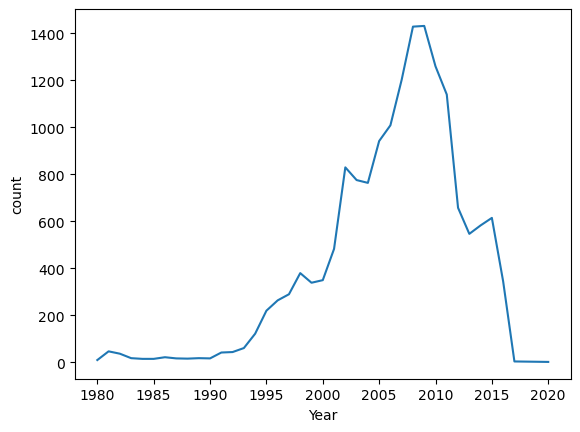

In [101]:
sns.lineplot(data= time_series_analysis,  x= "Year", y= "count")

In [113]:
time_series_analysis_by_sales = df.groupby("Year")["Global_Sales"].agg(["sum", "mean"]).reset_index()

In [114]:
time_series_analysis_by_sales.sort_values(by = "sum", ascending=False)

,Year,sum,mean
28,2008.0,678.90,0.475420
29,2009.0,667.30,0.466317
27,2007.0,611.13,0.508428
30,2010.0,600.45,0.476926
26,2006.0,521.04,0.516905
31,2011.0,515.99,0.453020
25,2005.0,459.94,0.488778
24,2004.0,419.31,0.549554
22,2002.0,395.52,0.477105
33,2013.0,368.11,0.674194


In [115]:
game_sales_df = pd.merge(time_series_analysis, time_series_analysis_by_sales, on = "Year")

In [118]:
game_sales_df

,Year,count,sum,mean
0,2009.0,1431,667.30,0.466317
1,2008.0,1428,678.90,0.475420
2,2010.0,1259,600.45,0.476926
3,2007.0,1202,611.13,0.508428
4,2011.0,1139,515.99,0.453020
5,2006.0,1008,521.04,0.516905
6,2005.0,941,459.94,0.488778
7,2002.0,829,395.52,0.477105
8,2003.0,775,357.85,0.461742
9,2004.0,763,419.31,0.549554


<Axes: xlabel='Year', ylabel='count'>

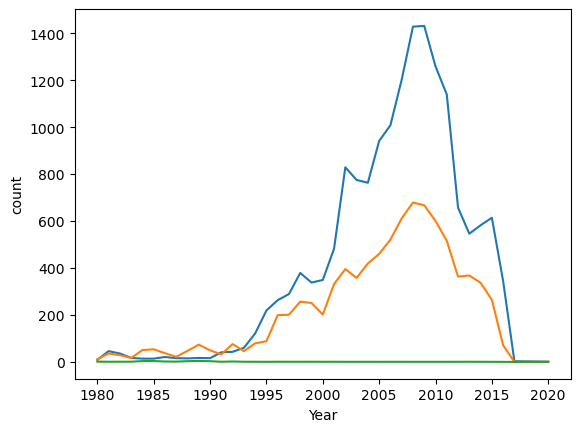

In [125]:
sns.lineplot(data= game_sales_df, x= "Year", y= "count")
sns.lineplot(data= game_sales_df, x= "Year", y= "sum")
sns.lineplot(data= game_sales_df, x= "Year", y= "mean")


<Axes: xlabel='Year', ylabel='mean'>

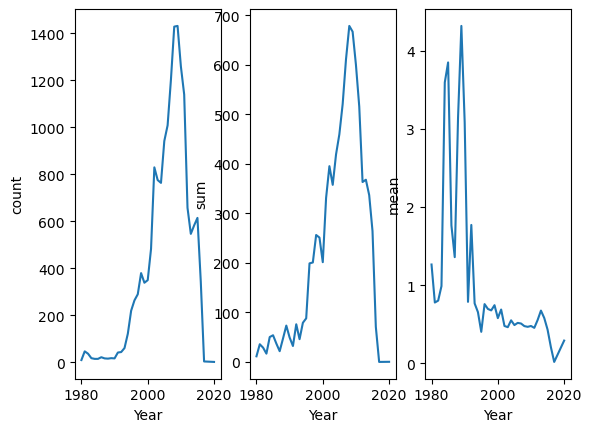

In [127]:
plt.subplot(1,3,1)
sns.lineplot(data= game_sales_df, x= "Year", y= "count")
plt.subplot(1,3,2)
sns.lineplot(data= game_sales_df, x= "Year", y= "sum")
plt.subplot(1,3,3)
sns.lineplot(data= game_sales_df, x= "Year", y= "mean")

In [136]:
df["Publisher"].value_counts().reset_index().head(10)

,Publisher,count
0,Electronic Arts,1351
1,Activision,975
2,Namco Bandai Games,932
3,Ubisoft,921
4,Konami Digital Entertainment,832
5,THQ,715
6,Nintendo,703
7,Sony Computer Entertainment,683
8,Sega,639
9,Take-Two Interactive,413


In [143]:
df["Publisher"].value_counts().unique().mean()

np.float64(169.39240506329114)

In [141]:
total_game = df["Name"].value_counts().unique().sum()

In [147]:
total_analysis = df[["Name", "Platform", "Year", "Genre", "Global_Sales"]].sort_values(by = "Global_Sales", ascending= False).head(10)

In [149]:
total_analysis["Platform"].value_counts()

Platform
Wii    5
NES    2
GB     2
DS     1
Name: count, dtype: int64

In [150]:
total_analysis["Genre"].value_counts()

Genre
Platform        3
Sports          2
Racing          1
Role-Playing    1
Puzzle          1
Misc            1
Shooter         1
Name: count, dtype: int64

In [153]:
df.groupby("Platform")["Global_Sales"].agg(["sum", "count"]).sort_values(by = "sum", ascending=False)

,sum,count
Platform,,
PS2,1255.64,2161
X360,979.96,1265
PS3,957.84,1329
Wii,926.71,1325
DS,822.49,2163
PS,730.66,1196
GBA,318.50,822
PSP,296.28,1213
PS4,278.10,336


In [158]:
df.groupby("Publisher")["Global_Sales"].agg(["sum", "count", "median", "mean"]).sort_values(by = "sum", ascending=False).head(20)

,sum,count,median,mean
Publisher,,,,
Nintendo,1786.56,703,0.890,2.541337
Electronic Arts,1110.32,1351,0.480,0.821850
Activision,727.46,975,0.280,0.746113
Sony Computer Entertainment,607.50,683,0.340,0.889458
Ubisoft,474.72,921,0.210,0.515440
Take-Two Interactive,399.54,413,0.300,0.967409
THQ,340.77,715,0.270,0.476601
Konami Digital Entertainment,283.64,832,0.150,0.340913
Sega,272.99,639,0.190,0.427214


In [165]:
df.groupby(["Platform", "Genre"])["Global_Sales"].agg(["count", "sum", "mean"]).sort_values(by = "sum", ascending=False).head(5)

count     sum      mean
Platform Genre                           
PS3      Action     380  307.88  0.810211
Wii      Sports     261  292.06  1.119004
X360     Shooter    203  278.55  1.372167
PS2      Sports     400  273.41  0.683525
         Action     348  272.76  0.783793